# Prior Sampling with a Uniform Distribution 
Creating prior samples from a uniform distribution with expanded bounds (and using rho instead of alpha/(\sqrt{N})

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import GFmodel as gf
import PlotClouds as PlotClouds
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

In [ ]:
def test_fun(num_s):
    samples = np.zeros((num_s,4))
    count = 0
    for i in range(0, num_s): 
        uniform = np.zeros(4)
        uniform[0] = np.random.uniform(0, 4000) #H_0
        uniform[1] = np.random.uniform(0, 720) #tau in minutes
        uniform[2] = np.random.uniform(0, 720) #T 
        uniform[3] = np.random.uniform(0, 1e-2/1440) #rho
        if gf.prior(uniform) == 1: 
            samples[count] = uniform
            count = count + 1
            print("The number of samples is:", count, 'and total iterations is', i, end = "\r")
    return samples[:count]

In [ ]:
# num_s = 10000
# my_samples = test_fun(num_s)
file_path = "gf_model/files/prior/exp03_prior_samples/"
my_samples = np.loadtxt((file_path + "prior_samples_%d.txt") %0, delimiter = ',') 
for ii in range(1, 10):
    add_samples = np.loadtxt((file_path + "prior_samples_%d.txt") %ii, delimiter = ',') 
    my_samples = np.concatenate((my_samples, add_samples), axis = 0)

np.savetxt(("gf_model/files/prior/prior_samples_exp03.txt"), my_samples, delimiter = ',') 

[3.58320864e+03 4.22794102e+02 8.33435208e+01 1.54198860e-08]


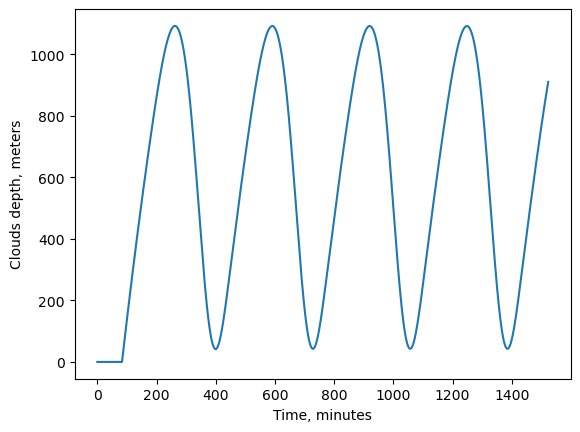

In [3]:
samp = my_samples[68]
print(samp)
dt = 0.1
solve_time = 1440
Hint = 0.1*np.ones(len(np.arange(0,samp[2]+dt,dt)))
check_oscillations = gf.dim_RK4(samp[0], samp[1], samp[2], samp[3], 
                                Hint, solve_time, dt)
plt.figure()
plt.plot(np.arange(0, solve_time + samp[2], dt), check_oscillations)
plt.xlabel("Time, minutes")
plt.ylabel("Clouds depth, meters")
plt.show()


In [4]:
#color map settings
viridis = cm.get_cmap('magma', 256)
newcolors = viridis(np.linspace(0, 1, 256))
pink = np.array([1, 1, 1, 1])
newcolors[:10, :] = pink
newcmp = ListedColormap(newcolors)

/var/folders/5l/8vvzlz7j559_wl1fjgbkr0680036qr/T/ipykernel_52920/226307041.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('magma', 256)


In [5]:
# plot_concat = np.loadtxt('files/prior_exp/all_uniform_new_prior_sam.txt', delimiter = ',')
plot_concat = my_samples
print(plot_concat.shape)
plot_concat[:,3] = plot_concat[:,3]*1440
plot_concat[:,0] = plot_concat[:,0]/1000

plot_concat = plot_concat.reshape((1, len(plot_concat[:,0]), 4))

(101521, 4)


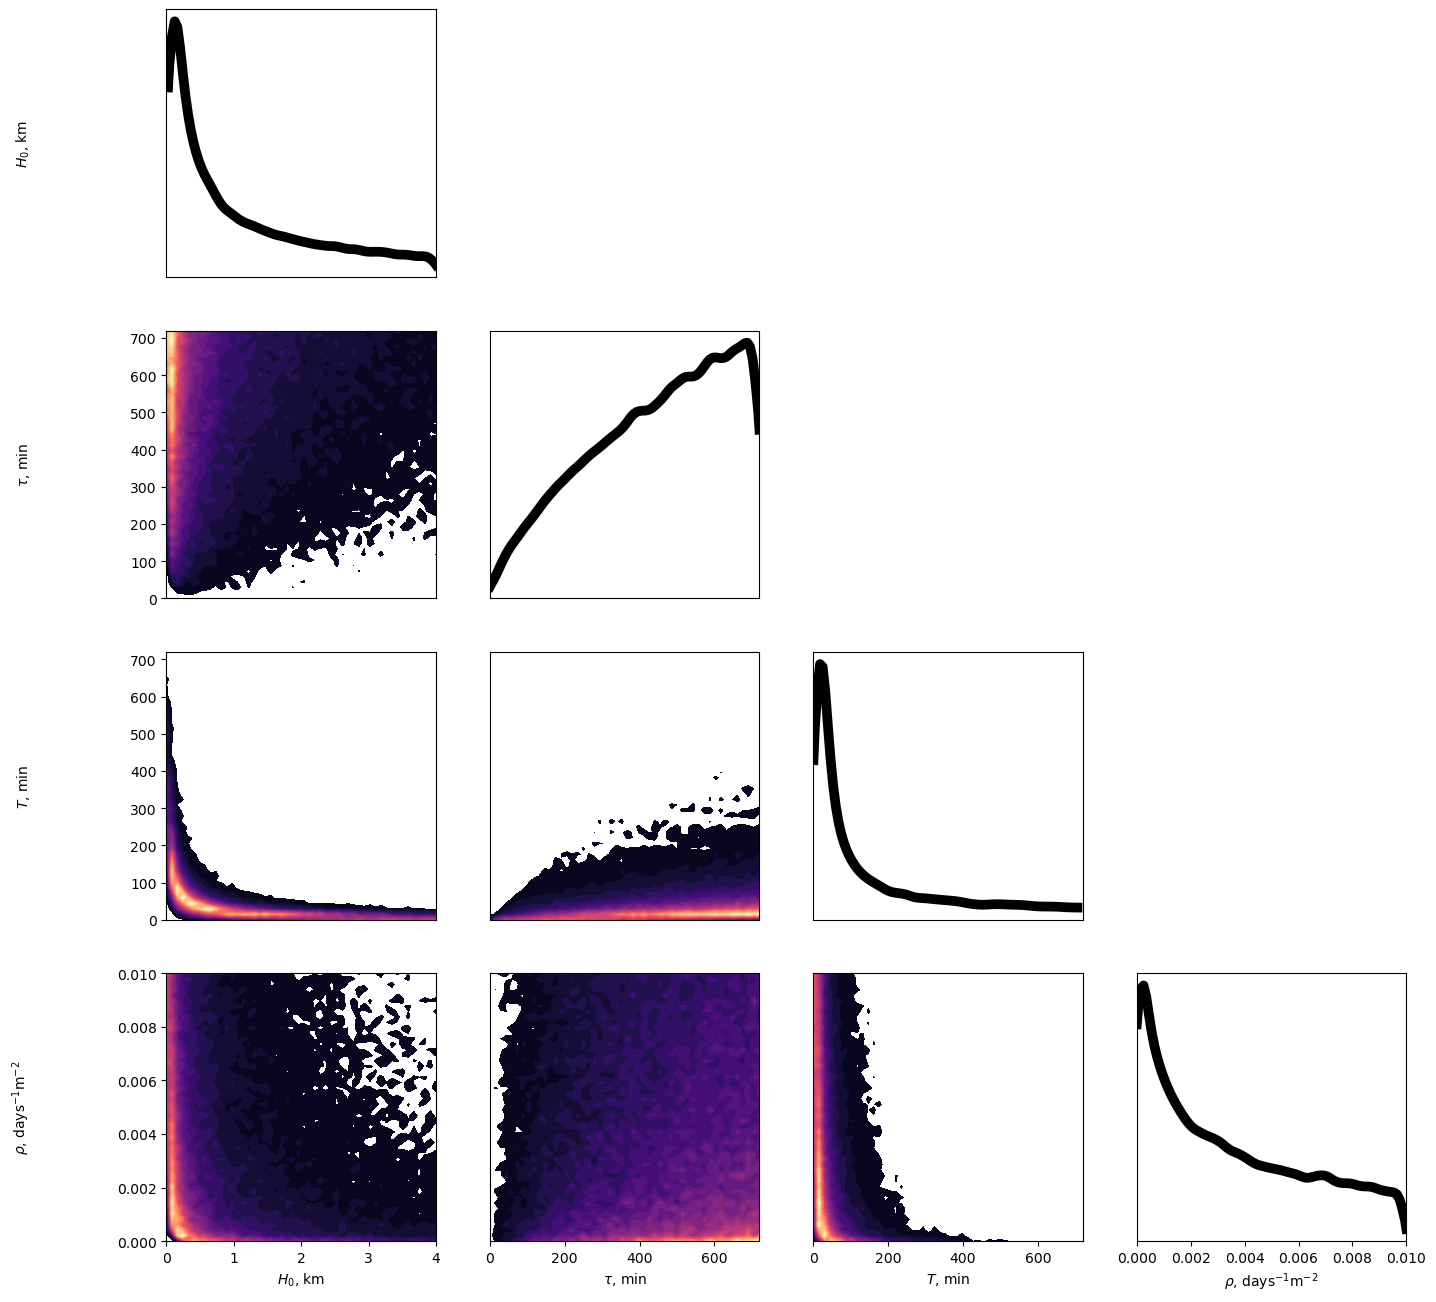

In [7]:
PlotClouds.contours(plot_concat, cmap_hist= newcmp ,linewidth= 7,fill_contours = True ,nLevels = 25,
                     bounds = [[0,4],[0,720],[0,720],[0, 1e-2]],nBins = 50, labels = 
                   ['$H_0$, km','$\\tau$, min','$T$, min','$\\rho$, days${}^{-1}$m${}^{-2}$'])

plt.show()